<a href="https://colab.research.google.com/github/nknak-crypto/Machine-Learning-Supervisado/blob/main/c2_knn_clasificaci_n_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Sección de Librerías
import pandas as pd
# Librerías de Science Kit para Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# Lee el archivo de clasificación de clientes
df = pd.read_csv('knn_client_classification (1).csv')
print(df.head(10))

   Age  Income  Visits_Last_Month  Avg_Purchase_Value  Months_as_Client  \
0   56    9901                 11              375.56                36   
1   69    6575                 11              295.85                56   
2   46    6530                  4              481.46                32   
3   32    5413                  6              193.69                52   
4   60    4748                  3              150.00                21   
5   25    1663                  5              435.61                20   
6   38    2998                 12              119.56                 5   
7   56    8994                 19              481.98                 5   
8   36    2495                 14               15.96                54   
9   40    4304                  2              485.24                47   

      Client_Type  
0  High Potential  
1          Stable  
2          Stable  
3          Stable  
4          Stable  
5          Stable  
6          Stable  
7  High Potent

In [ ]:
print('--- Reporte EDA ---')

# List column names
print('\nColumnas en el DataFrame:')
for col in df.columns:
    print(f'- {col}')

# Number of rows
print(f'\n# de Filas: {df.shape[0]}')

# Check for empty rows (missing values)
print('\nValores faltantes por Columna:')
print(df.isnull().sum())

--- Reporte EDA ---

Columnas en el DataFrame:
- Age
- Income
- Visits_Last_Month
- Avg_Purchase_Value
- Months_as_Client
- Client_Type

# de Filas: 200

Valores faltantes por Columna:
Age                   0
Income                0
Visits_Last_Month     0
Avg_Purchase_Value    0
Months_as_Client      0
Client_Type           0
dtype: int64


### Preparación de Datos para la Clasificación KNN

Primero, necesitamos separar nuestras **variables** ó **características** (los datos de entrada que usaremos para predecir, usualmente llamados `X`) de nuestra **variable objetivo** (lo que queremos predecir, usualmente llamado `y`). En nuestro caso, la columna `Client_Type` será nuestra variable objetivo. Como el algoritmo KNN funciona mejor con números, también convertiremos (`codificaremos`) los tipos de cliente categóricos (como 'Alto Potencial', 'Estable') en valores numéricos.

In [ ]:

# Separamos las variables independientes (X) y la variable objetivo (y)
# X contendrá todas las columnas excepto 'Client_Type'
X = df.drop('Client_Type', axis=1)

# y contendrá solo la columna 'Client_Type'
y = df['Client_Type']

# Codificamos la variable objetivo. Por ejemplo, 'High Potential' podría ser 0 y 'Stable' podría ser 1.
# LabelEncoder es una herramienta que nos ayuda a hacer esto automáticamente.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Tipos de Cliente Originales (codificados): {label_encoder.inverse_transform([0, 1])}")
print(f"Primeros 5 Tipos de Cliente Codificados: {y_encoded[:5]}\n")

# Dividimos los datos en conjuntos de entrenamiento y prueba.
# El 70% de los datos se usará para 'entrenar' el modelo (aprender patrones).
# El 30% restante se usará para 'probar' qué tan bien funciona el modelo con datos nuevos.
# 'random_state' asegura que siempre obtengamos la misma división si corremos el código múltiples veces.
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"Forma de X_train (filas, columnas): {X_train.shape}")
print(f"Forma de X_test (filas, columnas): {X_test.shape}")
print(f"Forma de y_train (solo filas): {y_train.shape}")
print(f"Forma de y_test (solo filas): {y_test.shape}")

Tipos de Cliente Originales (codificados): ['High Potential' 'New']
Primeros 5 Tipos de Cliente Codificados: [0 3 3 3 3]

Forma de X_train (filas, columnas): (140, 5)
Forma de X_test (filas, columnas): (60, 5)
Forma de y_train (solo filas): (140,)
Forma de y_test (solo filas): (60,)


### Escalado de Variables (Feature Scaling)

Los algoritmos como KNN se basan en la **distancia** entre los puntos de datos. Si una característica (como 'Ingresos') tiene valores mucho mayores que otra (como 'Visitas_Ultimo_Mes'), la característica con valores más grandes podría dominar el cálculo de la distancia. Para evitar esto, **escalamos** nuestras características, lo que significa ajustarlas para que todas tengan una escala similar. Usaremos `StandardScaler` que transforma los datos para que tengan una media de 0 y una desviación estándar de 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Inicializamos el StandardScaler. Piensa en esto como preparar la herramienta para escalar.
scaler = StandardScaler()

# Ajustamos el escalador a los datos de entrenamiento y luego transformamos tanto los datos de entrenamiento como los de prueba.
# 'fit_transform' aprende las reglas de escalado de X_train y las aplica.
# 'transform' solo aplica las reglas aprendidas a X_test.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Características escaladas con éxito.")
print(f"Primeras 5 filas de X_train escalado:\n{X_train_scaled[:5]}")

Características escaladas con éxito.
Primeras 5 filas de X_train escalado:
[[ 1.05807620e+00  5.58882211e-01  1.34469784e+00  1.37500568e+00
  -1.18834756e+00]
 [ 9.25757606e-01 -6.08955144e-01 -5.87050923e-01  4.12252619e-01
   3.25031687e-02]
 [-4.72566415e-04  4.52932438e-01 -5.87050923e-01 -1.10134958e+00
  -1.02186791e+00]
 [-1.98950461e-01 -1.01363548e+00  9.93470792e-01  8.79041844e-02
  -1.02186791e+00]
 [-7.94384143e-01 -7.16384345e-02  9.93470792e-01 -1.48795176e+00
   1.36434033e+00]]


### Entrenamiento y Predicción del Modelo K-Nearest Neighbors (KNN)

Ahora que nuestros datos están preparados y escalados, podemos construir y entrenar nuestro modelo KNN. El algoritmo KNN es un **clasificador perezoso** (lazy learner), lo que significa que no 'aprende' un modelo explícito durante el entrenamiento. En cambio, simplemente memoriza los datos de entrenamiento y realiza los cálculos solo cuando se le pide que haga una predicción. Para una nueva muestra, busca los `k` vecinos más cercanos en el conjunto de entrenamiento y asigna la clase que sea más común entre esos vecinos.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Inicializamos el clasificador KNN. 'n_neighbors=5' significa que consideraremos los 5 vecinos más cercanos.
# Puedes experimentar con diferentes valores de k (número de vecinos).
knn_model = KNeighborsClassifier(n_neighbors=5)

# Entrenamos el modelo usando los datos de entrenamiento escalados y sus etiquetas (y_train).
# Aquí es donde el modelo 'memoriza' los puntos de datos.
knn_model.fit(X_train_scaled, y_train)

# Hacemos predicciones sobre los datos de prueba escalados.
# El modelo usa lo que 'memorizó' para predecir el tipo de cliente para cada fila en X_test_scaled.
y_pred = knn_model.predict(X_test_scaled)

print("Modelo KNN entrenado y predicciones realizadas.")
print(f"Primeras 10 predicciones del modelo: {y_pred[:10]}")
print(f"Primeras 10 etiquetas verdaderas (reales): {y_test[:10]}")

Modelo KNN entrenado y predicciones realizadas.
Primeras 10 predicciones del modelo: [3 0 3 3 3 3 0 3 0 0]
Primeras 10 etiquetas verdaderas (reales): [3 3 3 3 2 3 0 3 3 0]


### Evaluación del Modelo: Matriz de Confusión

Después de hacer las predicciones, necesitamos saber qué tan bueno es nuestro modelo. Una **matriz de confusión** es una tabla que nos ayuda a visualizar el rendimiento de un algoritmo de clasificación. Muestra cuántas predicciones fueron correctas y cuántas incorrectas, y los tipos de errores que el clasificador está cometiendo (por ejemplo, cuántos clientes de 'Alto Potencial' fueron clasificados erróneamente como 'Estables', y viceversa).

También calcularemos el **Accuracy Score** (precisión general) y un **Reporte de Clasificación** para obtener métricas más detalladas como precisión, recall y f1-score.

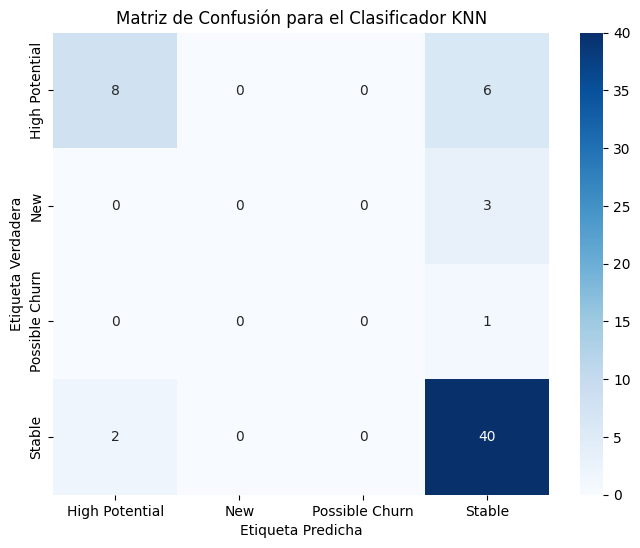


Reporte de Clasificación:
                precision    recall  f1-score   support

High Potential       0.80      0.57      0.67        14
           New       0.00      0.00      0.00         3
Possible Churn       0.00      0.00      0.00         1
        Stable       0.80      0.95      0.87        42

      accuracy                           0.80        60
     macro avg       0.40      0.38      0.38        60
  weighted avg       0.75      0.80      0.76        60


Accuracy Score (Precisión): 0.8000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Generamos la matriz de confusión comparando las etiquetas verdaderas (y_test) con las predichas (y_pred).
conf_matrix = confusion_matrix(y_test, y_pred)

# Creamos una figura para visualizar la matriz de confusión de una manera fácil de entender.
plt.figure(figsize=(8, 6))
# Usamos seaborn para dibujar un 'heatmap' (mapa de calor) de la matriz.
# 'annot=True' muestra los números dentro de las celdas.
# 'fmt='d'' formatea los números como enteros.
# 'cmap='Blues'' usa un esquema de color azul.
# 'xticklabels' y 'yticklabels' asignan los nombres reales a los ejes (por ejemplo, 'High Potential', 'Stable').
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión para el Clasificador KNN')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.show()

# Imprimimos un reporte de clasificación para ver métricas más detalladas.
# Esto incluye precisión (precision), recall, f1-score y soporte (support) para cada clase.
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Calculamos y mostramos el Accuracy Score (precisión general).
# Este es el porcentaje de predicciones correctas sobre el total de predicciones.
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score (Precisión): {accuracy:.4f}")

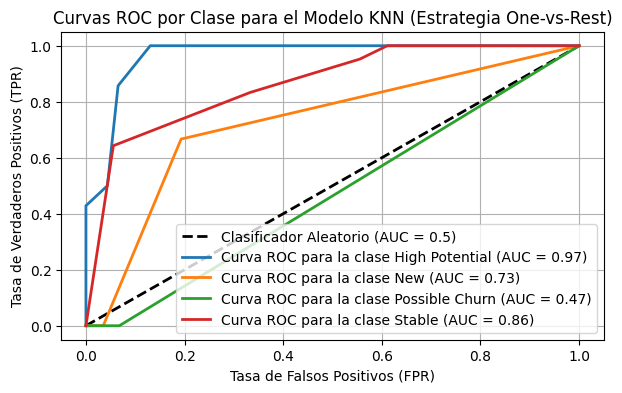

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# La Curva ROC (Receiver Operating Characteristic) y el AUC (Area Under the Curve)
# son herramientas muy importantes para evaluar clasificadores, especialmente
# cuando hay un desequilibrio de clases o cuando los costos de diferentes
# tipos de errores son distintos.
# El AUC es una medida de la capacidad del modelo para distinguir entre clases.
# Cuanto mayor sea el AUC, mejor será el rendimiento del modelo.
# Un AUC de 1.0 significa un clasificador perfecto, mientras que un AUC de 0.5
# indica un clasificador que no es mejor que adivinar al azar (la línea diagonal).

# 1. Obtener las probabilidades de predicción para cada clase
# Para calcular la curva ROC, necesitamos las probabilidades que el modelo asigna
# a cada clase para cada instancia, no solo la clase predicha final (y_pred).
# `predict_proba` nos da estas probabilidades para el conjunto de prueba escalado.
p_pred = knn_model.predict_proba(X_test_scaled)

# 2. Binarizar las etiquetas verdaderas para cada clase (Estrategia One-vs-Rest)
# Como tenemos múltiples clases (`High Potential`, `Stable`, etc.), necesitamos
# convertir las etiquetas `y_test` en un formato "uno contra el resto" (one-hot encoding).
# Esto significa que para cada clase, crearemos una nueva columna donde 1 indica
# que la instancia pertenece a esa clase y 0 indica que no pertenece a esa clase.
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

# Obtener el número de clases
n_classes = y_test_binarized.shape[1]

# 3. Calcular la Curva ROC y el AUC para cada clase
# Almacenaremos las tasas de falsos positivos (fpr), tasas de verdaderos positivos (tpr)
# y el AUC para cada clase.
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # `roc_curve` calcula los valores FPR y TPR para diferentes umbrales.
    # Compara las etiquetas binarizadas de la clase `i` con las probabilidades
    # predichas para esa misma clase `i`.
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], p_pred[:, i])
    # `auc` calcula el área bajo la curva ROC.
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Trazar las Curvas ROC
plt.figure(figsize=(7, 4))

# Primero, trazamos una línea diagonal de referencia. Esta línea representa
# un clasificador aleatorio. Un buen modelo debería estar muy por encima de esta línea.
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio (AUC = 0.5)')

# Trazamos la curva ROC para cada clase
for i in range(n_classes):
    # Usamos `label_encoder.classes_` para obtener los nombres reales de las clases
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Curva ROC para la clase {label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})')

# Añadir títulos y etiquetas al gráfico
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC por Clase para el Modelo KNN (Estrategia One-vs-Rest)')
plt.legend(loc='lower right') # Muestra la leyenda en la esquina inferior derecha
plt.grid(True) # Añade una cuadrícula para facilitar la lectura
plt.show()

# --- Interpretación de los resultados ---
# Observando el gráfico, los estudiantes pueden ver cómo se comporta el modelo
# para cada tipo de cliente. Una curva que se acerca a la esquina superior izquierda
# (TPR alto, FPR bajo) y tiene un AUC cercano a 1.0 indica un buen rendimiento
# para esa clase específica. Curvas cercanas a la línea diagonal o con AUC bajos
# (cercanos a 0.5) sugieren que el modelo tiene dificultades para distinguir esa
# clase de las demás.
#
# En este caso, podemos observar qué clases el modelo KNN clasifica mejor y cuáles
# peor en términos de equilibrio entre verdaderos positivos y falsos positivos.


**Interpretación de los Resultados:**

El gráfico de Curvas ROC muestra cómo se comporta tu modelo KNN para cada tipo de cliente. Para cada clase, puedes ver la Tasa de Verdaderos Positivos (TPR) frente a la Tasa de Falsos Positivos (FPR) en diferentes umbrales de clasificación. La línea discontinua negra representa un clasificador aleatorio (AUC = 0.5).

Los valores de AUC (Área bajo la Curva ROC) para cada clase son:

* High Potential: AUC = 0.97
* New: AUC = 0.73
* Possible Churn: AUC = 0.47
* Stable: AUC = 0.86

**Observaciones Clave:**

**High Potential (Alto Potencial):** El modelo tiene un rendimiento excelente para esta clase, con un AUC cercano a 1.0. Su curva está muy por encima de la línea aleatoria, indicando una gran capacidad para distinguir a los clientes de 'Alto Potencial' de los demás.
Stable (Estable): También muestra un buen rendimiento, aunque ligeramente inferior a 'High Potential', con un AUC de 0.86. El modelo es bastante bueno identificando a estos clientes.
New (Nuevo): El rendimiento para esta clase es aceptable, con un AUC de 0.73, lo que sugiere que el modelo tiene cierta capacidad para identificar a los clientes 'Nuevos', aunque hay margen de mejora.

**Possible Churn (Posible Baja)**: El modelo tiene dificultades significativas con esta clase, con un AUC de 0.47, lo que está incluso por debajo de un clasificador aleatorio (0.5). Esto indica que el modelo no puede diferenciar efectivamente a los clientes en 'Posible Baja' de las otras clases. Esto podría ser debido a la escasez de datos para esta clase o a la falta de características distintivas en el conjunto de datos.

En resumen, el modelo KNN funciona bien para las clases 'High Potential' y 'Stable', de manera moderada para 'New', pero muy mal para 'Possible Churn'. Esto coincide con las observaciones que hicimos en la matriz de confusión y el reporte de clasificación, donde las clases 'New' y 'Possible Churn' tuvieron un recall y precision de 0, lo que se refleja en sus bajos AUCs. Esto destaca la importancia de evaluar el modelo con métricas adecuadas para clases desequilibradas.

In [ ]:
# 1. Crear un DataFrame con las características originales del conjunto de prueba (X_test)
# Aseguramos que X_test es un DataFrame si aún no lo es, y reseteamos el índice para facilitar la unión.
results_df = X_test.copy()

# 2. Añadir la columna de tipo de cliente real (original) al DataFrame
# Utilizamos `label_encoder.inverse_transform` para convertir las etiquetas numéricas `y_test` a sus nombres originales.
results_df['Original_Client_Type'] = label_encoder.inverse_transform(y_test)

# 3. Añadir la columna de tipo de cliente predicho al DataFrame
# Similarmente, convertimos las predicciones numéricas `y_pred` a sus nombres originales.
results_df['Predicted_Client_Type'] = label_encoder.inverse_transform(y_pred)

# 4. Mostrar el DataFrame resultante
# Puedes ajustar el número de filas a mostrar si es necesario.
print("Tabla de Clientes de Prueba con Tipos Originales y Predichos:")
print(results_df.head(10))

# Opcional: Mostrar todas las filas del DataFrame si el conjunto de prueba no es muy grande
# pd.set_option('display.max_rows', None)
# print(results_df)
# pd.reset_option('display.max_rows') # Para restaurar la configuración por defecto

Tabla de Clientes de Prueba con Tipos Originales y Predichos:
     Age  Income  Visits_Last_Month  Avg_Purchase_Value  Months_as_Client  \
95    42    5973                 18               24.10                54   
15    41    4581                  9              281.39                23   
30    66    6791                 15              145.92                27   
158   56    2686                  8              100.42                52   
128   65    8339                  3               78.03                 4   
115   52    4436                  4              464.03                21   
69    19    6534                 17              499.86                12   
170   46    3806                  1              260.72                41   
174   24    9716                 18              270.98                28   
45    26    7287                 11              413.04                 7   

    Original_Client_Type Predicted_Client_Type  
95                Stable                S

# Matriz de Confusión y Reporte de Clasificación:

**El Accuracy Score general del modelo es 0.8000**, lo que significa que el 80% de las predicciones fueron correctas.

El Reporte de Clasificación y la Matriz de Confusión nos dan más detalles:

**High Potential (Alto Potencial)**: El modelo predijo correctamente 8 clientes de este tipo, pero confundió 6 como 'Stable'. Su precisión es del 80% y su recall del 57%.
New (Nuevo): Había 3 clientes 'New' en el conjunto de prueba, pero el modelo no predijo correctamente ninguno de ellos, clasificándolos todos como 'Stable'. Por eso, su precisión y recall son 0%. Recibimos una advertencia (UndefinedMetricWarning) porque no se predijo ninguna muestra para esta clase.

**Possible Churn (Posible Baja):** Similarmente, el único cliente 'Possible Churn' fue clasificado incorrectamente como 'Stable'. Su precisión y recall también son 0%, con la misma advertencia.
Stable (Estable): El modelo fue muy bueno prediciendo clientes 'Stable', acertando 40 de ellos. Solo confundió 2 con 'High Potential'. Su precisión es del 80% y su recall del 95%.
En resumen, el modelo es bueno identificando clientes 'Stable' y 'High Potential', pero tiene dificultades para identificar correctamente a los clientes 'New' y 'Possible Churn'. Esto podría deberse a que hay muy pocas muestras de estas clases en los datos de prueba, o a que las características no son suficientes para diferenciarlos.

